#EDA Insurance

## Funciones EDA

In [ ]:
def calculos_boxplot(columna, coef=1.5):
    """
    Calcula el Rango Intercuartílico (IQR) y los límites para valores considerados
    válidos (no extremos).
    -------------------------------
    Parametros de entrada:
    - columna: columna de un dataframe o Serie de Pandas
    - coef: valor del coeficiente para el cálculo de los límites válidos, por defecto 1.5
        Se puede ampliar si se quiere "relajar" la exigencia para dichos valores

    -------------------------------
    SALIDA:
    Devuelve una tupla (limite_inferior, limite_superior)
    y muestra por pantalla información

    """

    Q1, Q3 = columna.quantile([0.25,0.75])

    IQR = Q3 - Q1

    lim_inferior = Q1 - coef*IQR
    lim_superior = Q3 + coef*IQR

    print('Cuartiles: ', Q1, '\t', Q3)
    print('IQR: ',IQR)
    print('Limite inferior: ', lim_inferior)
    print('Limite superior: ', lim_superior)

    return lim_inferior, lim_superior


In [ ]:
def categoricas_unicos(dataframe, var_cat, vc_out=True):
    """
    Muestra valores unicos y conteo de las variables categóricas.
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_cat: lista de variables categóricas (cadena)
    - vc_out: booleano para mostrar o no (True/False) el resultado de "value_counts()"
        Por defecto lo muestra

    -------------------------------
    SALIDA:
    No devuelve valor. Saca por pantalla la información

    """

    for discreta in var_cat:

        print(f'Variable {discreta.upper()}:')
        print('Valores unicos: ')
        print(dataframe[discreta].unique(), end='\n'*2)

        if vc_out:
            print(dataframe[discreta].value_counts(), end='\n'*2)





In [ ]:
def graf_histo_box_numericas(dataframe, var_num):
    """
    Realiza graficas histograma y boxplot de variables numéricas de un dataframe
    -------------------------------
    Parametros de entrada:
    - dataframe: DF de pandas
    - var_num: lista de variables numéricas (cadena)

    -------------------------------
    SALIDA:
    No devuelve valor. Dibuja las gráficas por pantalla

    """

    TABLEAU_CMP = ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', \
                   'tab:gray','tab:olive', 'tab:cyan')

    fig, axes = plt.subplots(len(var_num), 2, \
                             figsize=(20, 5 * len(var_num)), \
                             gridspec_kw={'hspace': 0.4, 'wspace': 0.1})
    ax = axes.ravel()

    # graficas distribucion y boxplot de cada atributo
    for idx, atributo in enumerate(var_num):

        # distribucion (histograma)
        sns.histplot(dataframe[atributo], ax=ax[2 * idx], \
                     color=TABLEAU_CMP[idx % len(TABLEAU_CMP)], \
                     alpha=0.15, kde=True)

        # titulo, etiquetas histograma
        ax[2 * idx].set_title(f'HISTOGRAMA {atributo}')
        ax[2 * idx].set_xlabel(f'Valores {atributo}')
        ax[2 * idx].set_ylabel("Frequencia")

        # boxplot
        sns.boxplot(x=atributo, data=dataframe, ax=ax[2 * idx + 1], color=TABLEAU_CMP[idx % len(TABLEAU_CMP)])

        # titulo, etiquetas boxplot
        ax[2 * idx + 1].set_title(f'BOXPLOT {atributo}')
        ax[2 * idx + 1].set_xlabel(f'Valores {atributo}')



## Importación de datos

In [ ]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importación de datos
ruta = 'https://raw.githubusercontent.com/SonikoKatsura/CURSO_PARO_IA/refs/heads/main/Rober_IA/Modulo1/datos/insurance.csv'

df_insurance = pd.read_csv(ruta)
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Identificación de variables numéricas y categóricas

In [ ]:
# Identificación de variables numéricas y categóricas
variables_numericas = df_insurance.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df_insurance.select_dtypes(include=['object']).columns.tolist()

print("Variables numéricas:", variables_numericas)
print("Variables categóricas:", variables_categoricas)


Variables numéricas: ['age', 'bmi', 'children', 'charges']
Variables categóricas: ['sex', 'smoker', 'region']


## Información

In [ ]:
# Información
df_insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## Ordenar columnas por nombre

In [ ]:
# Ordenar columnas por nombre
df_insurance = df_insurance.reindex(sorted(df_insurance.columns), axis=1)
df_insurance.columns

Index(['age', 'bmi', 'charges', 'children', 'region', 'sex', 'smoker'], dtype='object')

## Eliminar duplicados

In [ ]:
# Eliminar duplicados
df_insurance.drop_duplicates(inplace=True)
display(df_insurance.duplicated().sum())

np.int64(0)

## Descripción

In [ ]:
# Descripción
df_insurance.describe()

,age,bmi,charges,children
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,13279.121487,1.095737
std,14.044333,6.100468,12110.359656,1.205571
min,18.000000,15.960000,1121.873900,0.000000
25%,27.000000,26.290000,4746.344000,0.000000
50%,39.000000,30.400000,9386.161300,1.000000
75%,51.000000,34.700000,16657.717450,2.000000
max,64.000000,53.130000,63770.428010,5.000000


## Separar variables numéricas y categóricas

In [ ]:
# Separar variables numéricas y categóricas
var_numericas = df_insurance.select_dtypes(exclude=['object']).columns.to_list()
var_categoricas = df_insurance.select_dtypes(include=['object']).columns.to_list()
print("Variables numéricas:", var_numericas)
print("Variables categóricas:", var_categoricas)

Variables numéricas: ['age', 'bmi', 'children', 'charges']
Variables categóricas: ['sex', 'smoker', 'region']


##Análisis univariante

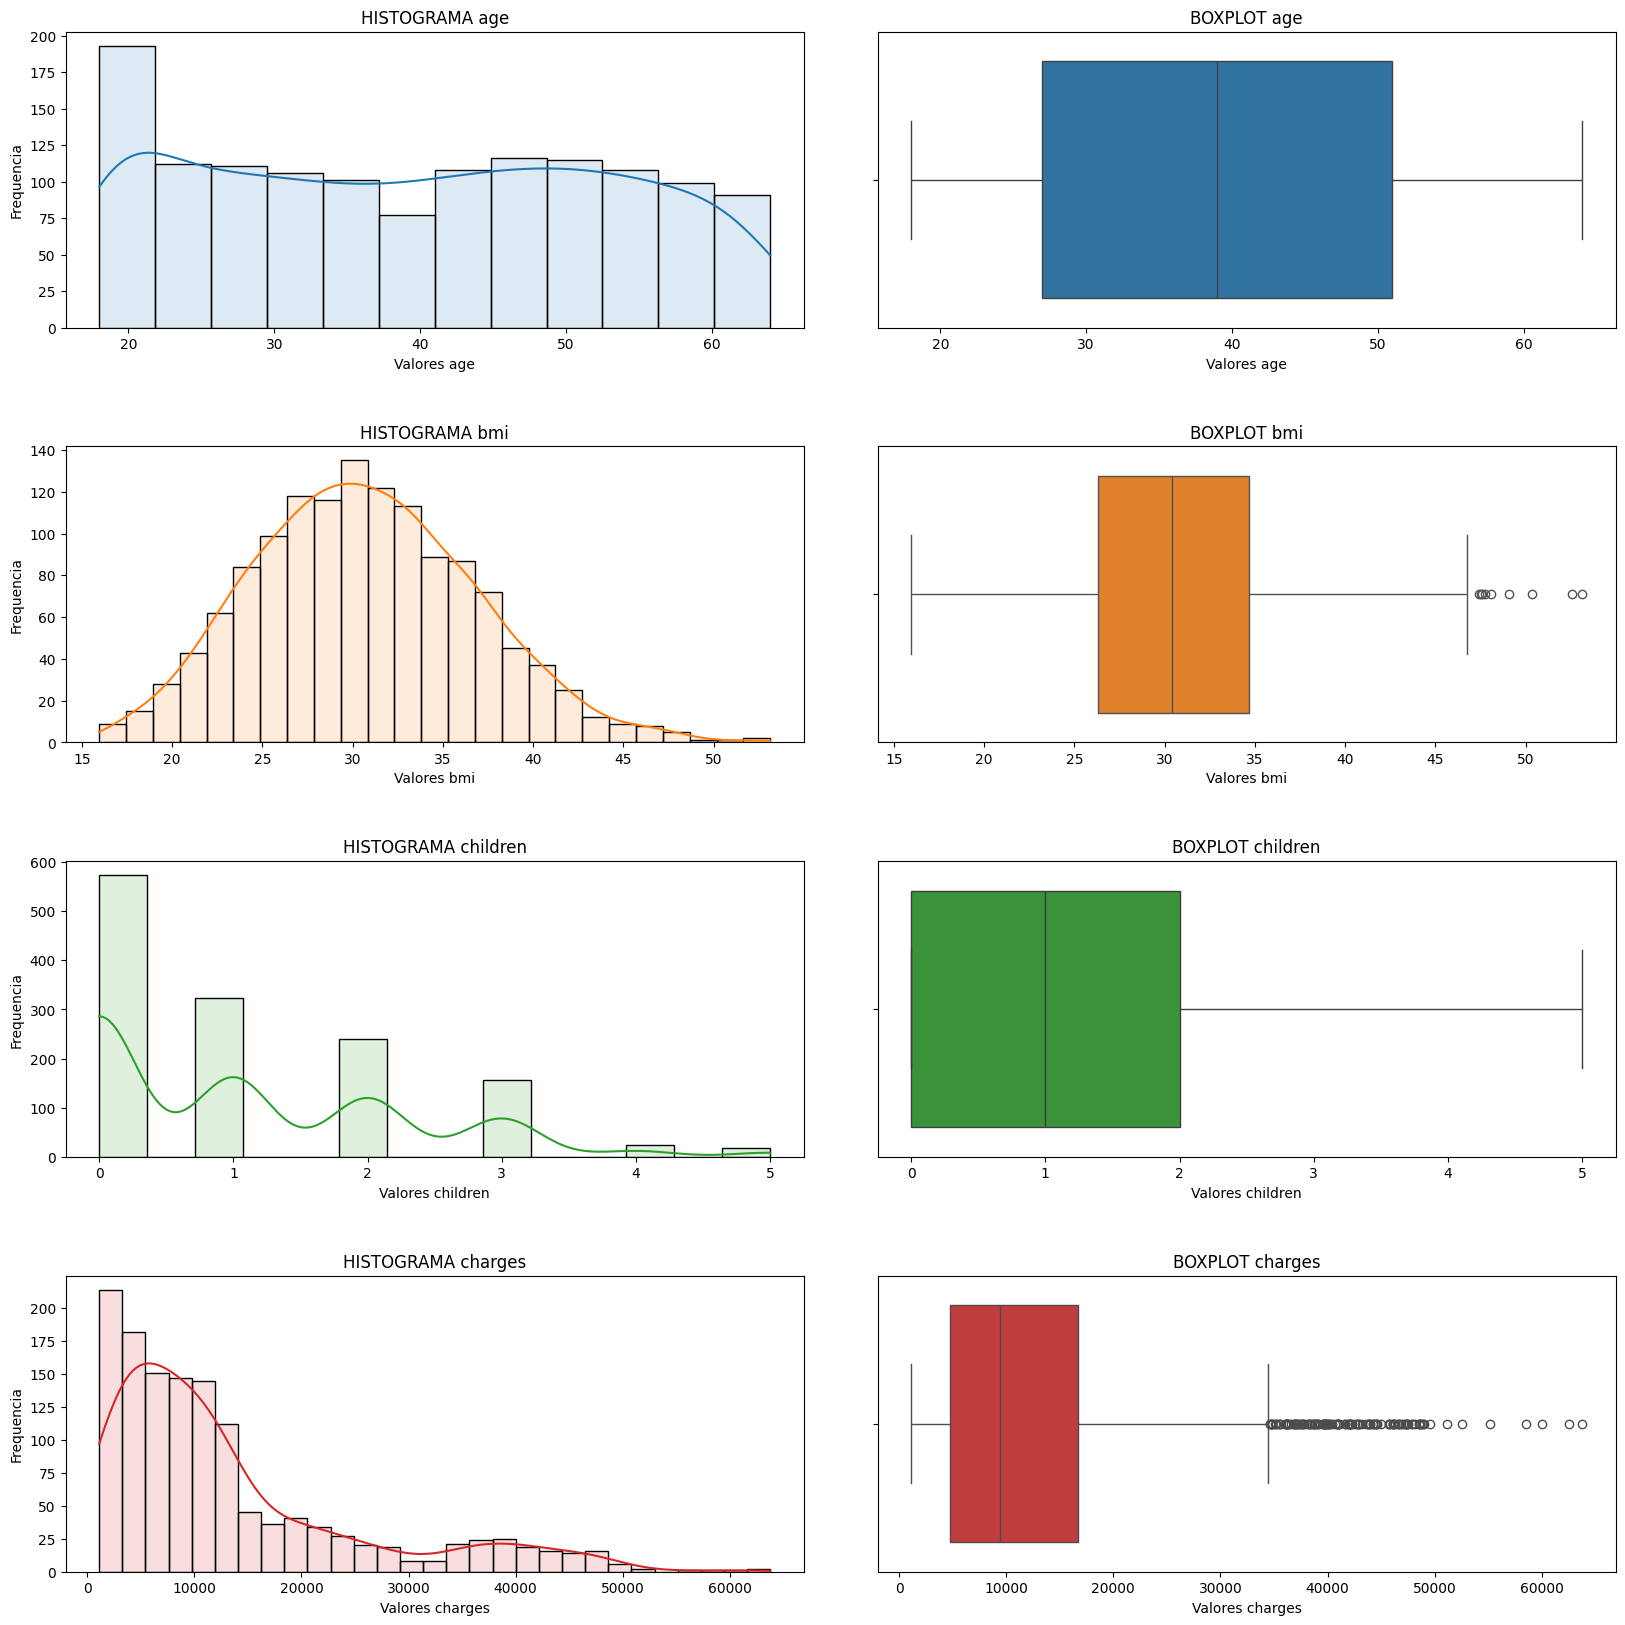

In [ ]:
#Análisis univariante
graf_histo_box_numericas(df_insurance, var_numericas)

##Gráficas Categórica

<ipython-input-66-2123892489>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=columna, data=df_insurance, ax=ax[idx], palette='tab10')
<ipython-input-66-2123892489>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=columna, data=df_insurance, ax=ax[idx], palette='tab10')
<ipython-input-66-2123892489>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=columna, data=df_insurance, ax=ax[idx], palette='tab10')


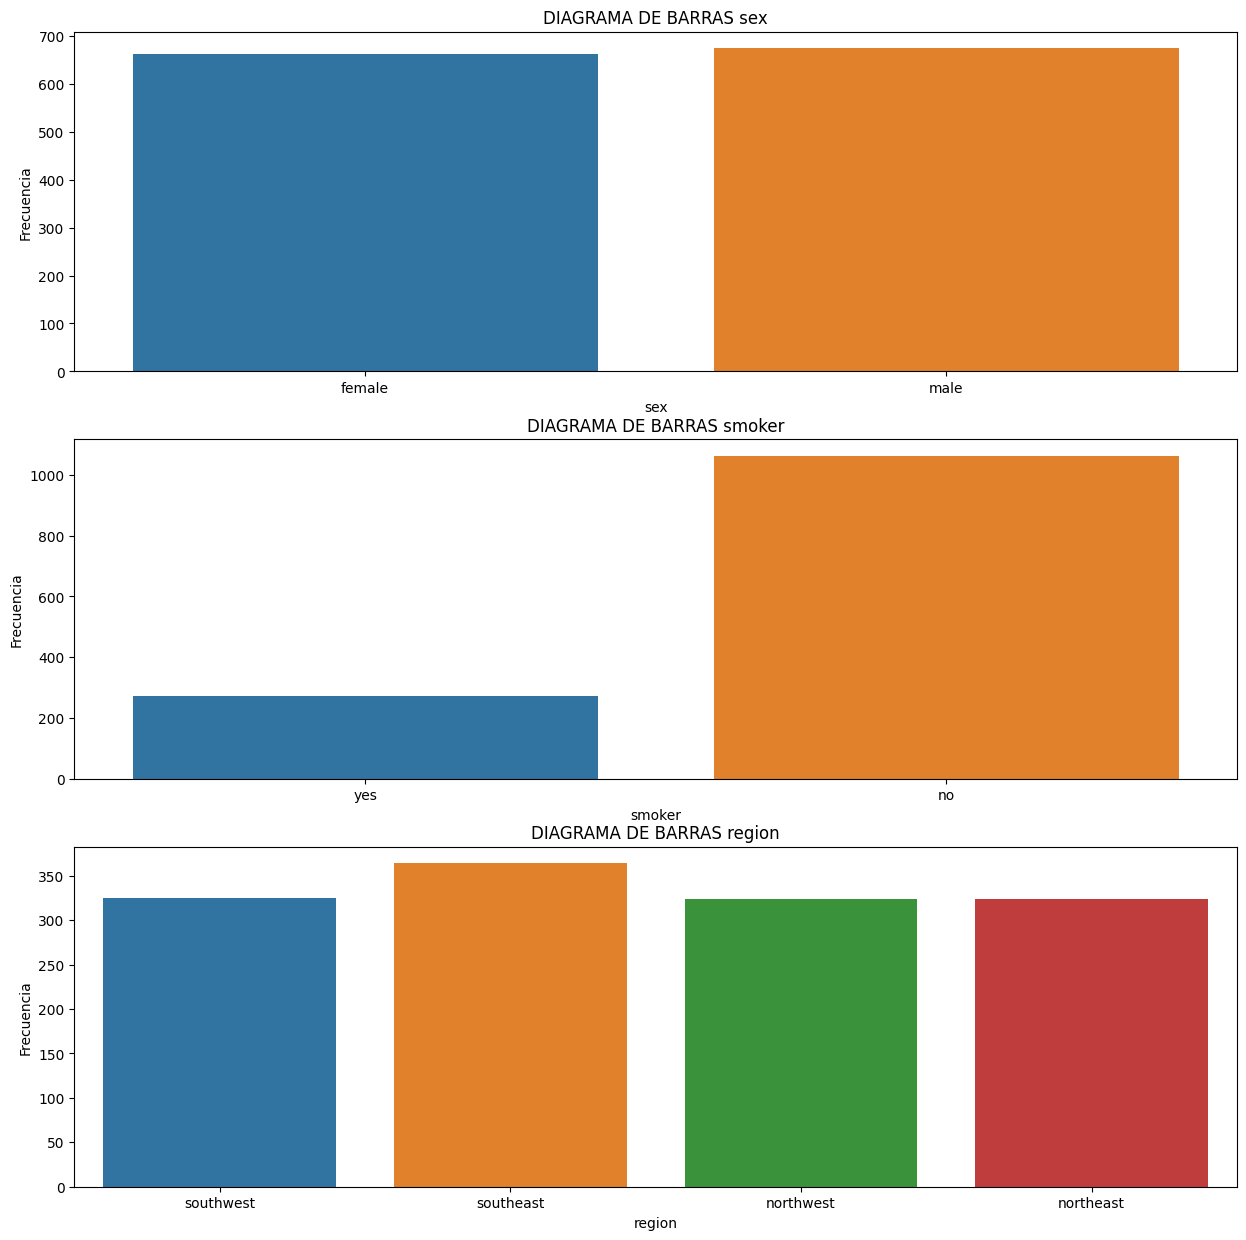

In [ ]:
#Gráficas Categórica
fig, ax = plt.subplots(len(var_categoricas), 1, figsize=(15, 5 * len(var_categoricas)))


for idx, columna in enumerate(var_categoricas):

    sns.countplot(x=columna, data=df_insurance, ax=ax[idx], palette='tab10')

    ax[idx].set_title(f'DIAGRAMA DE BARRAS {columna}')
    ax[idx].set_xlabel(columna)
    ax[idx].set_ylabel('Frecuencia')

##Análisis bidireccional

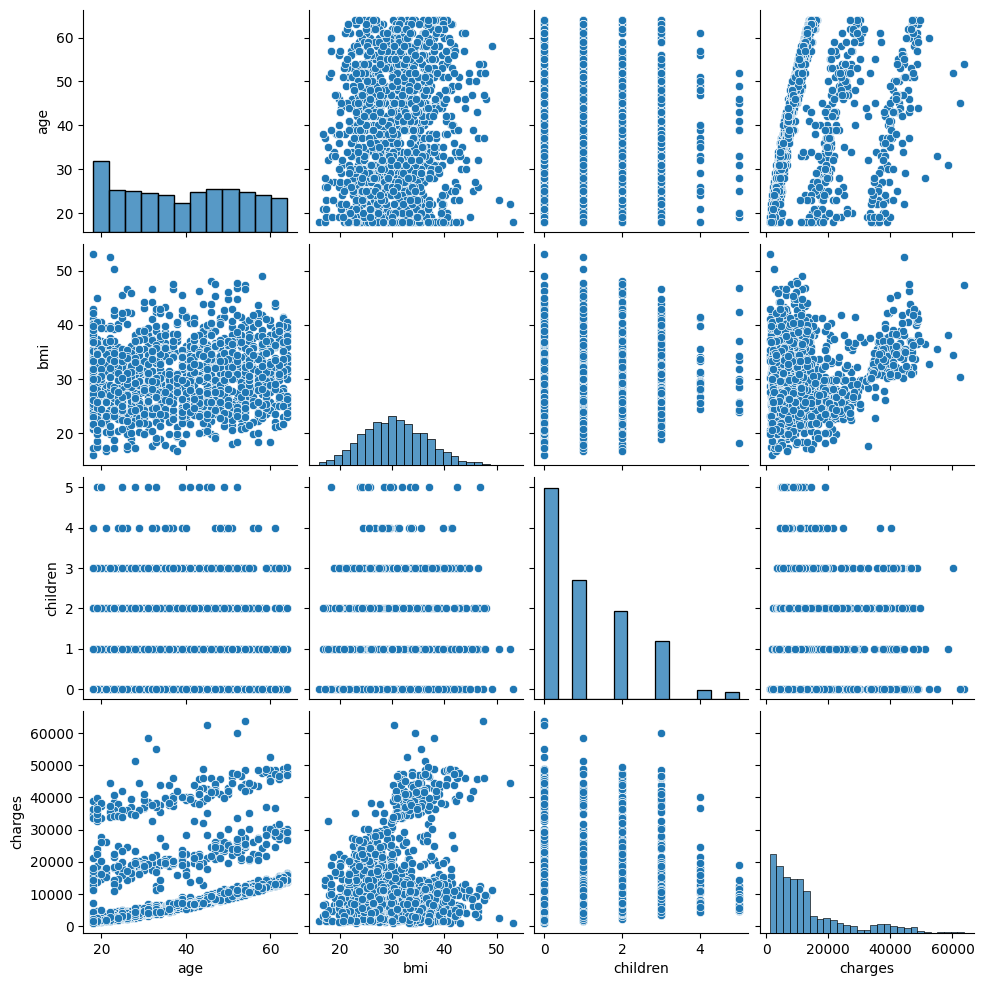

In [ ]:
#Análisis bidireccional
sns.pairplot(df_insurance[var_numericas])

## Matriz correlacion

In [ ]:
# Matriz correlacion(calculamos la correlacion (metodo "corr") del dataframe de columnas numéricas)
mat_corr = df_insurance.corr(numeric_only=True)

display(mat_corr)

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


## Mapa de calor

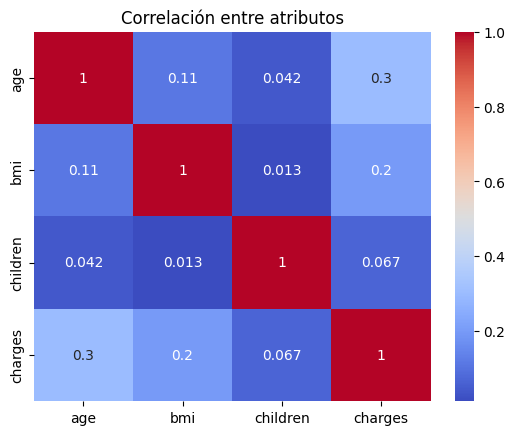

In [ ]:
# Heatmap para representar gráficamente la matriz de correlación

sns.heatmap(mat_corr, annot=True, cbar=True, cmap=sns.color_palette("coolwarm", as_cmap=True))
plt.title('Correlación entre atributos');

##Análisis de outliers

In [ ]:
#Análisis de outliers
for col in var_numericas:
  print(f'Análisis de outliers para la columna: {col}')
  lim_inferior, lim_superior = calculos_boxplot(df_insurance[col])
  print("-" * 30)

Análisis de outliers para la columna: age
Cuartiles:  27.0 	 51.0
IQR:  24.0
Limite inferior:  -9.0
Limite superior:  87.0
------------------------------
Análisis de outliers para la columna: bmi
Cuartiles:  26.29 	 34.7
IQR:  8.410000000000004
Limite inferior:  13.674999999999994
Limite superior:  47.31500000000001
------------------------------
Análisis de outliers para la columna: children
Cuartiles:  0.0 	 2.0
IQR:  2.0
Limite inferior:  -3.0
Limite superior:  5.0
------------------------------
Análisis de outliers para la columna: charges
Cuartiles:  4746.344 	 16657.71745
IQR:  11911.37345
Limite inferior:  -13120.716174999998
Limite superior:  34524.777625
------------------------------


## Relación entre las variables categóricas y numéricas.

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


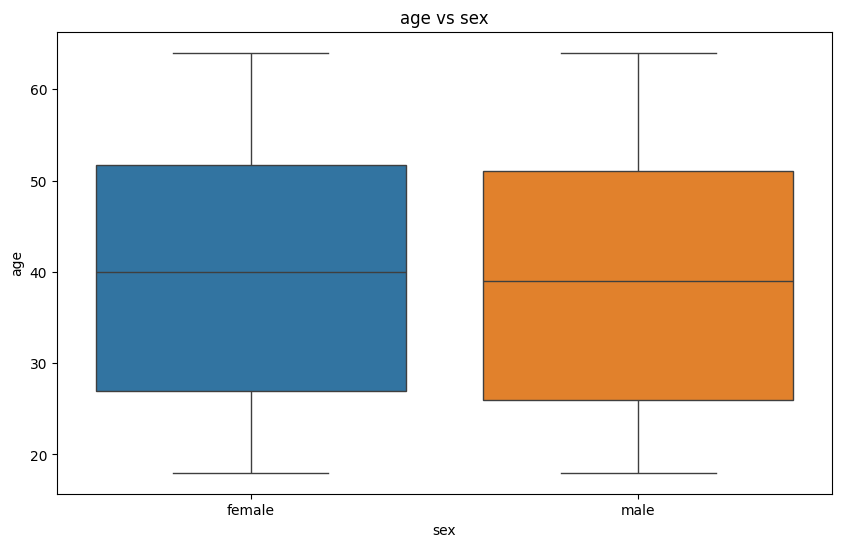

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


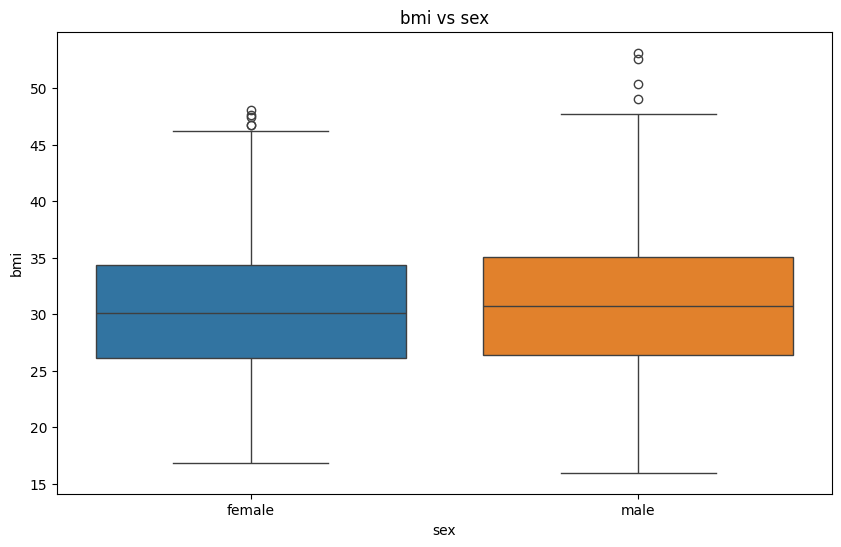

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


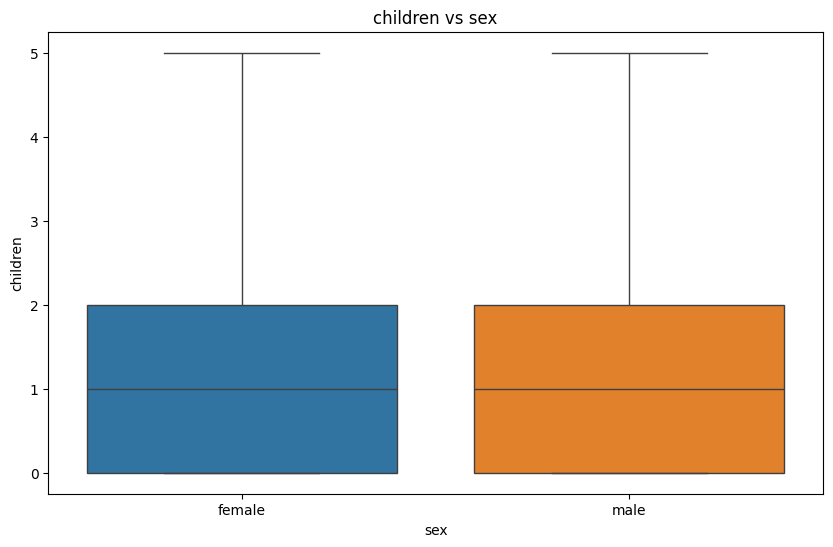

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


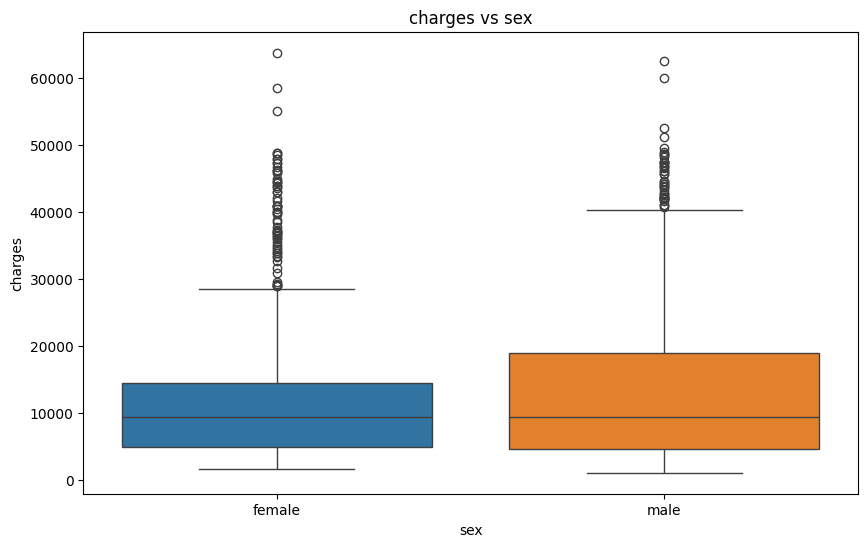

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


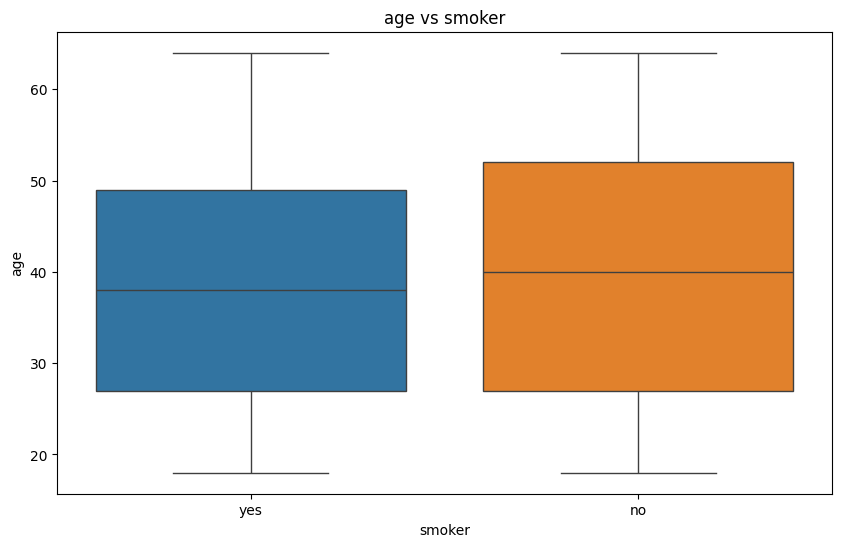

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


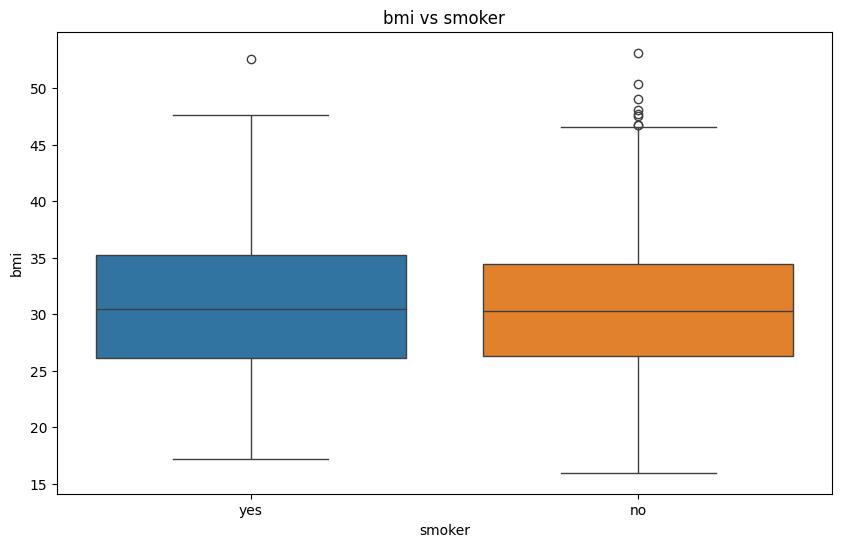

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


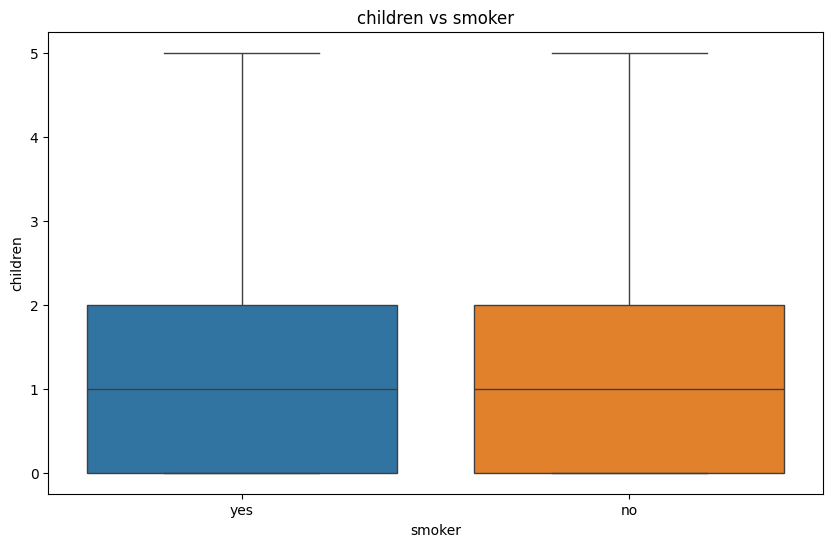

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


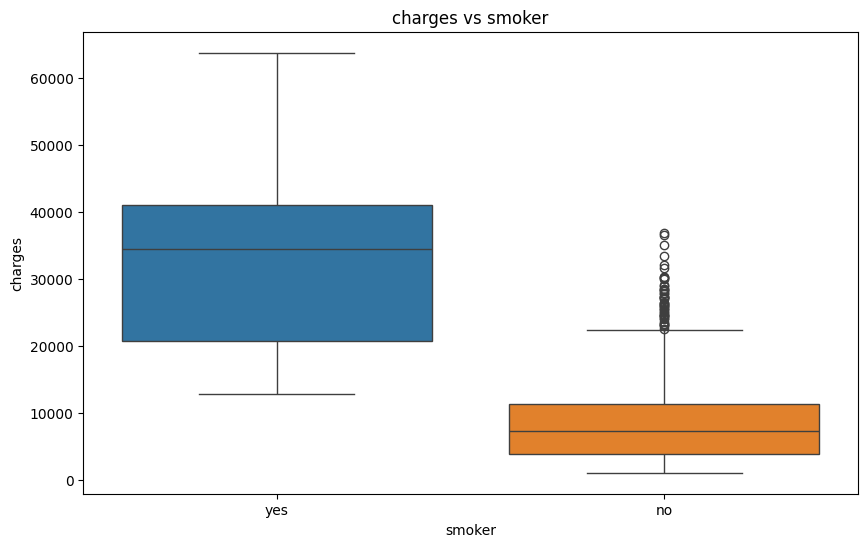

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


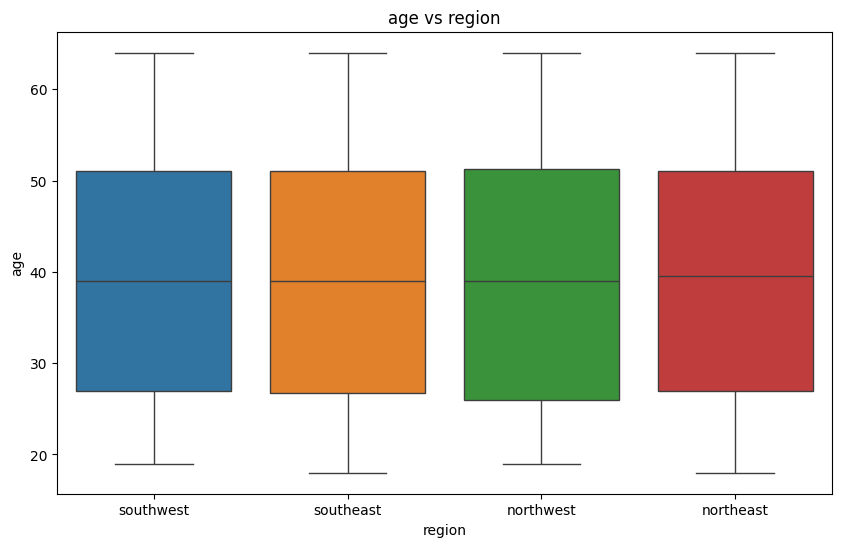

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


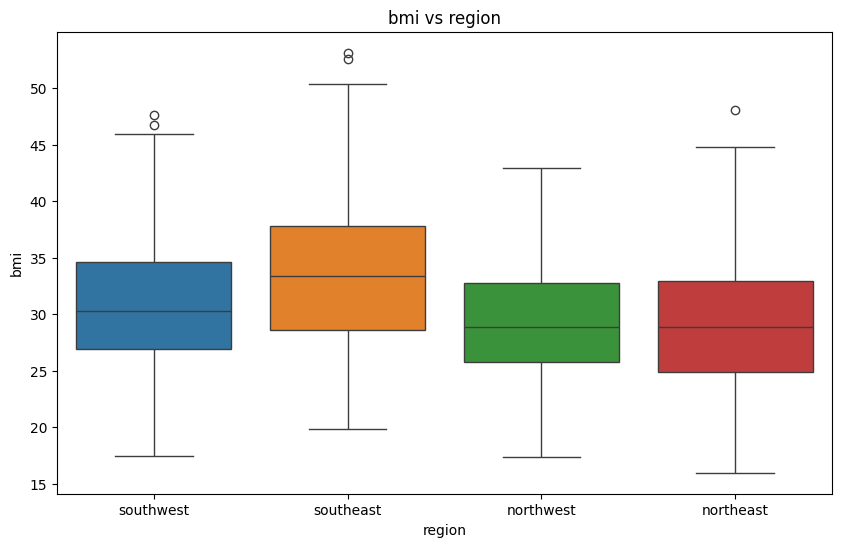

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


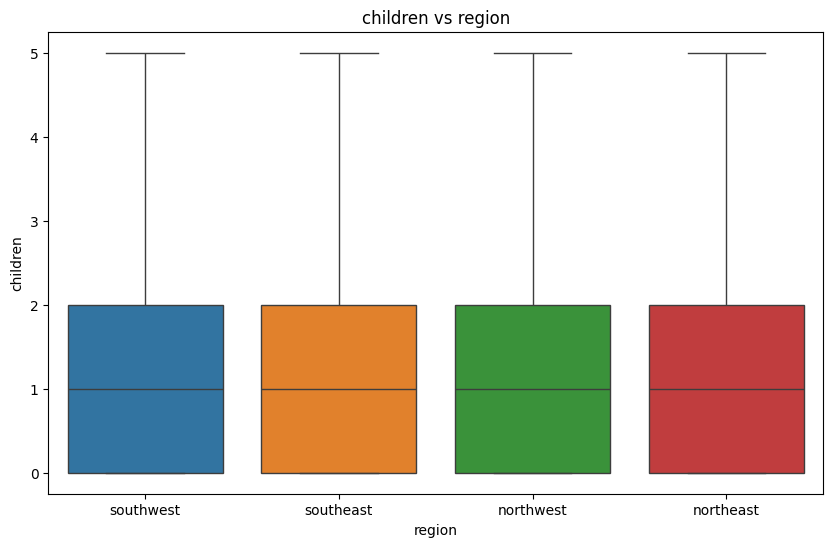

<ipython-input-68-858670618>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')


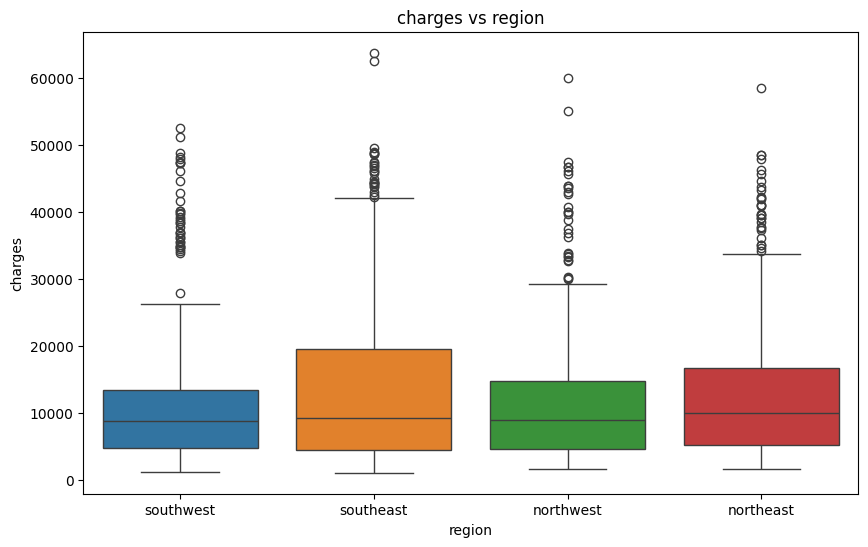

In [ ]:
# Relación entre las variables categóricas y numéricas.
for cat_col in var_categoricas:
    for num_col in var_numericas:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=cat_col, y=num_col, data=df_insurance, palette='tab10')
        plt.title(f'{num_col} vs {cat_col}')
        plt.show()

##Hallazgos clave del análisis de datos

* Las variables numéricas 'age' (edad) e 'bmi' (índice de masa corporal) muestran distribuciones cercanas a la normal, mientras que 'charges' (cargos) presenta un sesgo positivo significativo con valores atípicos importantes.
* Las variables categóricas 'sex' (sexo) y 'smoker' (fumador) son binarias, 'region' (región) tiene cuatro categorías y 'children' (hijos) representa el número de dependientes. La distribución de 'smoker' está desequilibrada, con significativamente menos fumadores.
* 'Smoker' es la variable categórica con mayor impacto en 'charges', con los fumadores teniendo costos de seguro considerablemente más altos.
* 'Age' y 'bmi' muestran una correlación positiva con 'charges', aunque no tan fuerte como la relación entre 'smoker' y 'charges'.
* Los valores atípicos en 'charges' son sustanciales y probablemente estén relacionados con factores como el estado de fumador.


##Conclusiones o próximos pasos

* La fuerte relación entre fumar y los costes sugiere que los programas o políticas para dejar de fumar podrían ser un enfoque para reducir los costes de seguro.
* Una investigación adicional sobre los valores atípicos en 'charges' podría revelar otros factores significativos que influyen en los costes y que no están explícitamente capturados en las variables actuales.

##Analizar el impacto de 'smoker' en 'charges'

<ipython-input-70-681569638>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df_insurance, palette='viridis')


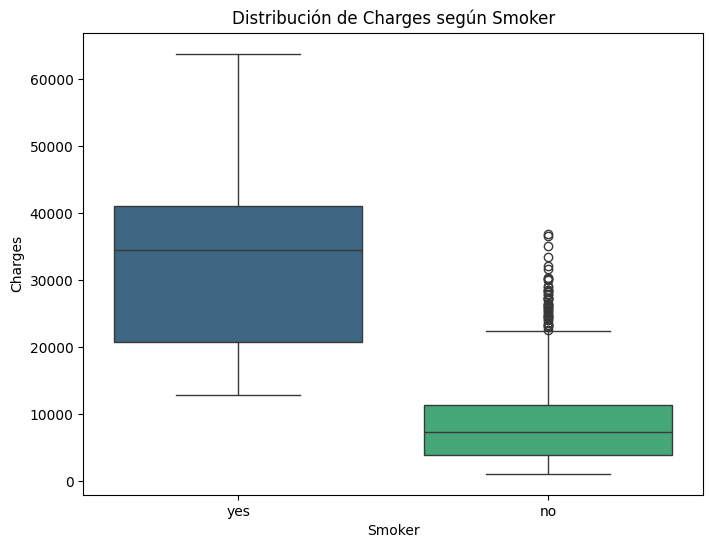

In [ ]:
#Analizar el impacto de 'smoker' en 'charges'

plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df_insurance, palette='viridis')
plt.title('Distribución de Charges según Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

##**Modelando fumadores y no fumadores por separado**

Debido a que la diferencia entre fumadores y no fumadores es tan grande, modelar a fumadores y no fumadores por separado puede ser beneficioso porque:

* **Las relaciones dentro de cada grupo pueden ser diferentes:** Los factores que influyen en los costes de un fumador podrían ser distintos a los que influyen en los costes de un no fumador (quizás condiciones preexistentes, estilo de vida, etc.).
* **Mejor ajuste del modelo:** Un solo modelo puede tener dificultades para capturar la gran diferencia en la media y la variabilidad de los cargos entre los dos grupos. Entrenar modelos separados puede resultar en un mejor ajuste para cada subgrupo.
* **Interpretación más clara:** Es más fácil interpretar los coeficientes o la importancia de las características dentro de cada grupo si se modelan por separado.

### Dividir el DataFrame original en dos sub-DataFrames basados en la columna 'smoker'

In [ ]:
# Dividir el DataFrame original en dos sub-DataFrames basados en la columna 'smoker'

# DataFrame para fumadores
df_smokers = df_insurance[df_insurance['smoker'] == 'yes'].copy()

# DataFrame para no fumadores
df_non_smokers = df_insurance[df_insurance['smoker'] == 'no'].copy()

# Mostrar las primeras filas de cada nuevo DataFrame para verificar la división
print("DataFrame de Fumadores:")
display(df_smokers.head())

print("\nDataFrame de No Fumadores:")
display(df_non_smokers.head())

DataFrame de Fumadores:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
11,62,female,26.29,0,yes,southeast,27808.7251
14,27,male,42.13,0,yes,southeast,39611.7577
19,30,male,35.30,0,yes,southwest,36837.4670
23,34,female,31.92,1,yes,northeast,37701.8768



DataFrame de No Fumadores:


,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


### Preprocesamiento para fumadores

In [ ]:
# Preprocesamiento para fumadores

# Identificar variables numéricas y categóricas en el DataFrame de fumadores
var_numericas_smokers = df_smokers.select_dtypes(exclude=['object']).columns.to_list()
var_categoricas_smokers = df_smokers.select_dtypes(include=['object']).columns.to_list()

print("Variables numéricas (Fumadores):", var_numericas_smokers)
print("Variables categóricas (Fumadores):", var_categoricas_smokers)

# Análisis y manejo de outliers en variables numéricas para fumadores
print("\n--- Análisis de Outliers (Fumadores) ---")
for col in var_numericas_smokers:
  print(f'Análisis de outliers para la columna: {col} (Fumadores)')
  lim_inferior, lim_superior = calculos_boxplot(df_smokers[col])
  # Aquí podrías añadir código para manejar los outliers, por ejemplo:
  # df_smokers = df_smokers[(df_smokers[col] >= lim_inferior) & (df_smokers[col] <= lim_superior)].copy()
  print("-" * 30)

# Aplicar transformaciones de las variables categóricas a formato numérico para fumadores
# Excluimos la columna 'smoker' ya que todos son 'yes' en este DataFrame
var_categoricas_smokers_encode = [col for col in var_categoricas_smokers if col != 'smoker']
df_smokers_encoded = pd.get_dummies(df_smokers, columns=var_categoricas_smokers_encode, drop_first=True)

# Separar la variable objetivo (charges)
X_smokers = df_smokers_encoded.drop('charges', axis=1)
y_smokers = df_smokers_encoded['charges']

print("\nDataFrame de Fumadores después de transformación y separación:")
display(X_smokers.head())
display(y_smokers.head())

Variables numéricas (Fumadores): ['age', 'bmi', 'children', 'charges']
Variables categóricas (Fumadores): ['sex', 'smoker', 'region']

--- Análisis de Outliers (Fumadores) ---
Análisis de outliers para la columna: age (Fumadores)
Cuartiles:  27.0 	 49.0
IQR:  22.0
Limite inferior:  -6.0
Limite superior:  82.0
------------------------------
Análisis de outliers para la columna: bmi (Fumadores)
Cuartiles:  26.083750000000002 	 35.2
IQR:  9.11625
Limite inferior:  12.409375
Limite superior:  48.874375
------------------------------
Análisis de outliers para la columna: children (Fumadores)
Cuartiles:  0.0 	 2.0
IQR:  2.0
Limite inferior:  -3.0
Limite superior:  5.0
------------------------------
Análisis de outliers para la columna: charges (Fumadores)
Cuartiles:  20826.2442125 	 41019.207275
IQR:  20192.9630625
Limite inferior:  -9463.200381249997
Limite superior:  71308.65186874999
------------------------------

DataFrame de Fumadores después de transformación y separación:


,age,bmi,children,smoker,sex_male,region_northwest,region_southeast,region_southwest
0,19,27.90,0,yes,False,False,False,True
11,62,26.29,0,yes,False,False,True,False
14,27,42.13,0,yes,True,False,True,False
19,30,35.30,0,yes,True,False,False,True
23,34,31.92,1,yes,False,False,False,False


,charges
0,16884.9240
11,27808.7251
14,39611.7577
19,36837.4670
23,37701.8768


### Preprocesamiento para no fumadores

In [ ]:
# Preprocesamiento para no fumadores

# Identificar variables numéricas y categóricas en el DataFrame de no fumadores
var_numericas_non_smokers = df_non_smokers.select_dtypes(exclude=['object']).columns.to_list()
var_categoricas_non_smokers = df_non_smokers.select_dtypes(include=['object']).columns.to_list()

print("Variables numéricas (No Fumadores):", var_numericas_non_smokers)
print("Variables categóricas (No Fumadores):", var_categoricas_non_smokers)

# Análisis y manejo de outliers en variables numéricas para no fumadores
print("\n--- Análisis de Outliers (No Fumadores) ---")
for col in var_numericas_non_smokers:
  print(f'Análisis de outliers para la columna: {col} (No Fumadores)')
  lim_inferior, lim_superior = calculos_boxplot(df_non_smokers[col])
  # Aquí podrías añadir código para manejar los outliers, por ejemplo:
  # df_non_smokers = df_non_smokers[(df_non_smokers[col] >= lim_inferior) & (df_non_smokers[col] <= lim_superior)].copy()
  print("-" * 30)

# Aplicar Aplicar transformaciones de las variables categóricas a formato numérico de los no fumadores
# Excluimos la columna 'smoker' ya que todos son 'no' en este DataFrame
var_categoricas_non_smokers_encode = [col for col in var_categoricas_non_smokers if col != 'smoker']
df_non_smokers_encoded = pd.get_dummies(df_non_smokers, columns=var_categoricas_non_smokers_encode, drop_first=True)

# Separar la variable objetivo (charges)
X_non_smokers = df_non_smokers_encoded.drop('charges', axis=1)
y_non_smokers = df_non_smokers_encoded['charges']

print("\nDataFrame de No Fumadores después de transformación y separación:")
display(X_non_smokers.head())
display(y_non_smokers.head())

Variables numéricas (No Fumadores): ['age', 'bmi', 'children', 'charges']
Variables categóricas (No Fumadores): ['sex', 'smoker', 'region']

--- Análisis de Outliers (No Fumadores) ---
Análisis de outliers para la columna: age (No Fumadores)
Cuartiles:  27.0 	 52.0
IQR:  25.0
Limite inferior:  -10.5
Limite superior:  89.5
------------------------------
Análisis de outliers para la columna: bmi (No Fumadores)
Cuartiles:  26.315 	 34.43
IQR:  8.114999999999998
Limite inferior:  14.142500000000004
Limite superior:  46.6025
------------------------------
Análisis de outliers para la columna: children (No Fumadores)
Cuartiles:  0.0 	 2.0
IQR:  2.0
Limite inferior:  -3.0
Limite superior:  5.0
------------------------------
Análisis de outliers para la columna: charges (No Fumadores)
Cuartiles:  3988.8835 	 11363.0191
IQR:  7374.1356
Limite inferior:  -7072.319899999999
Limite superior:  22424.222499999996
------------------------------

DataFrame de No Fumadores después de transformación y s

,age,bmi,children,smoker,sex_male,region_northwest,region_southeast,region_southwest
1,18,33.770,1,no,True,False,True,False
2,28,33.000,3,no,True,False,True,False
3,33,22.705,0,no,True,True,False,False
4,32,28.880,0,no,True,True,False,False
5,31,25.740,0,no,False,False,True,False


,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
